## analysing some miscallaneous changes post net zero using ACCESS net zero runs – such as SH sea ice extent and changes in poleward heat transport

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import os
import xarray as xr
import xcdat as xc

In [3]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as mticker
import pandas as pd


In [4]:
import netCDF4
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

In [5]:
import cmocean
from scipy import stats

In [6]:
mpl.rcParams['font.family'] = 'Droid Sans'
mpl.rcParams['font.size'] = 14
# Edit axes parameters
mpl.rcParams['axes.linewidth'] = 0.8
# Tick properties
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.minor.size'] = 3
mpl.rcParams['xtick.major.width'] = 1
mpl.rcParams['xtick.direction'] = 'out'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.minor.size'] = 3
mpl.rcParams['ytick.major.width'] = 1
mpl.rcParams['ytick.direction'] = 'out'

In [7]:
def plot_decorator():
    ax = plt.gca()
    
    # Minor ticks
    # ax.minorticks_on()
    # plt.tick_params(which='minor', axis='x', bottom=False)
    
    # Grid (light, behind data)
    ax.grid(color='gray', lw=0.4, alpha=0.1)
    
    # Remove top/right spines (Nature style)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Tight layout
    # plt.tight_layout()

In [8]:
from matplotlib.colors import BoundaryNorm as BM
# from matplotlib.colors import LogNorm as LM
import matplotlib.patches as mpatches

In [9]:
def plot_background(ax, draw_labels=False):
    ax.add_feature(cfeature.COASTLINE, alpha=0.9, lw=1.1)
    # ax.set_global()
    # ax.add_feature(cfeature.LAND, color='lightgray')
    # ax.add_feature(cfeature.OCEAN, color='lightgray')
    gl = ax.gridlines(draw_labels=draw_labels,
                      linewidth=1, color='gray', alpha=0.01, linestyle='--')
    gl.top_labels = False
    # gl.left_labels = False
    # gl.bottom_labels = False
    gl.right_labels = False
    gl.xlines = False
    # gl.xlocator = mticker.FixedLocator([-180, -45, 0, 45, 180])
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 10, 'color': 'k'}
    gl.ylabel_style = {'size': 10, 'color': 'k'}
    return ax


def plot_maps(x, y, z, titles, labels, cmap, levels, pval = [], draw_winds=False, u_wnd=[], v_wnd=[], wind_scale=20, draw_contour=False, contour_data=[], contour_levels=[], contour_colors='gray', 
            nrows=1, ncols=3, figsize=(12,4), land_mask_list = [0], add_patch=False, add_patch_extra=False, hatch_type = 'insig', proj=ccrs.Robinson(central_longitude=160), 
            cbar_kwargs=dict(orientation='vertical', label='Precip', aspect=40, shrink=0.7, pad=0.05), draw_labels=False, draw_colorbar=True, auto_aspect=False):

    fig, axarr = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, constrained_layout=False, subplot_kw={'projection':proj})
    
    axlist = axarr.flatten()
    
    for ax in axlist:
        if draw_labels:
            plot_background(ax, draw_labels)
        else:
            plot_background(ax)
        if auto_aspect:
            ax.set_aspect('auto')
        else:
            continue
    
    for i in range(len(z)):
        axlist[i].contourf(x, y, z[i], cmap = cmap, transform = ccrs.PlateCarree(central_longitude=0), levels=levels, extend='both')
        if draw_winds:
            wind_separation = 5
            q = axlist[i].quiver(x[::wind_separation, ::wind_separation], y[::wind_separation, ::wind_separation], u_wnd[i][::wind_separation, ::wind_separation], v_wnd[i][::wind_separation, ::wind_separation], scale=wind_scale, color='k', pivot='middle', transform=ccrs.PlateCarree())
            qk = ax.quiverkey(q, X=0.85, Y=0.9, U=1.0, label='1 m/s', labelpos='E', coordinates='axes')
            qk.text.set_bbox(dict(facecolor='white', edgecolor='k'))#, boxstyle='round,pad=0.3'))
        if draw_contour:
            axlist[i].contour(x, y, contour_data[i], cmap = None, levels=contour_levels, colors=contour_colors, transform = ccrs.PlateCarree(central_longitude=0), alpha=0.7)
        if i in land_mask_list:
            axlist[i].add_feature(cfeature.LAND, color = 'k', zorder=1)
        if pval != []:
            if hatch_type == 'insig':
                pval_plot = np.ma.masked_less_equal(pval[i], 0.05)
                axlist[i].pcolor(x, y, pval_plot, alpha = 0., hatch='/////', transform = ccrs.PlateCarree(central_longitude=0))
            elif hatch_type == 'sig':
                pval_plot = np.ma.masked_greater(pval[i], 0.05)
                axlist[i].pcolor(x, y, pval_plot, alpha = 0., hatch='...', transform = ccrs.PlateCarree(central_longitude=0))
        axlist[i].set_title(titles[i], fontdict={'fontsize':14})
        axlist[i].text(0.1, 1.05, labels[i], size=16, fontweight='bold', transform=axlist[i].transAxes)
        if add_patch:
            # axlist[i].add_patch(mpatches.Rectangle(xy=[120, -65], width=170, height=20,
            #                                 facecolor='none', edgecolor='k',
            #                                 transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[190, -5], width=80, height=10,
                                            facecolor='none', edgecolor='k',
                                            transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[140, -5], width=30, height=10,
                                            facecolor='none', edgecolor='k',
                                            transform=ccrs.PlateCarree()))
            # axlist[i].add_patch(mpatches.Rectangle(xy=[250, -30], width=40, height=20,
            #                                 facecolor='none', edgecolor='k',
            #                                 transform=ccrs.PlateCarree()))
            # axlist[i].add_patch(mpatches.Rectangle(xy=[140, 60], width=150, height=20,
            #                                             facecolor='none', edgecolor='tab:green', lw=1.5,
            #                                             transform=ccrs.PlateCarree()))
            # axlist[i].add_patch(mpatches.Rectangle(xy=[140, -80], width=150, height=20,
            #                                             facecolor='none', edgecolor='tab:green', lw=1.5,
            #                                             transform=ccrs.PlateCarree()))
        if add_patch_extra:
            axlist[i].add_patch(mpatches.Rectangle(xy=[190, 20], width=60, height=20,
                                                        facecolor='none', edgecolor='k', lw=1.5,
                                                        transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[210, -40], width=60, height=30,
                                                        facecolor='none', edgecolor='k', lw=1.5,
                                                        transform=ccrs.PlateCarree()))
                    
    if draw_colorbar:
        norm = BM(levels, 256, extend='both')
        fig.colorbar(mpl.cm.ScalarMappable(norm = norm, cmap=cmap), ax = axlist, \
                    orientation = cbar_kwargs['orientation'], shrink=cbar_kwargs['shrink'], aspect = cbar_kwargs['aspect'], pad = cbar_kwargs['pad'], label = cbar_kwargs['label'], ticks=levels[::2])



def plot_single_map(x, y, z, title, label, cmap, levels, pval = [], draw_winds=False, u_wnd=[], v_wnd=[], wind_scale=20, draw_contour=False, contour_data=[], contour_levels=[], contour_colors='gray', 
                figsize=(12,4), land_mask_list = False, add_patch=False, add_patch_extra=False, hatch_type = 'insig', proj=ccrs.Robinson(central_longitude=160), 
                cbar_kwargs=dict(orientation='vertical', label='Precip', aspect=40, shrink=0.7, pad=0.05), draw_labels=False, draw_colorbar=True, auto_aspect=False):

    ax = plt.axes(projection=proj)
    if draw_labels:
        plot_background(ax, draw_labels)
    else:
        plot_background(ax)
    if auto_aspect:
        ax.set_aspect('auto')
    
    cf=ax.contourf(x, y, z, cmap = cmap, transform = ccrs.PlateCarree(central_longitude=0), levels=levels, extend='both')
    if draw_winds:
        wind_separation = 5
        q = ax.quiver(x[::wind_separation, ::wind_separation], y[::wind_separation, ::wind_separation], u_wnd.to_numpy()[::wind_separation, ::wind_separation], v_wnd.to_numpy()[::wind_separation, ::wind_separation], scale=wind_scale, \
        color='k', transform=ccrs.PlateCarree())
        qk = ax.quiverkey(q, X=0.85, Y=0.9, U=1.0, label='1 m/s', labelpos='E', coordinates='axes')
        qk.text.set_bbox(dict(facecolor='white', edgecolor='k'))#, boxstyle='round,pad=0.3'))
    if draw_contour:
        ax.contour(x, y, contour_data, cmap = None, levels=contour_levels, colors=contour_colors, transform = ccrs.PlateCarree(central_longitude=0), alpha=0.7)
    if land_mask_list:
        ax.add_feature(cfeature.LAND, color = 'k', zorder=1)
    if pval != []:
        if hatch_type == 'insig':
            pval_plot = np.ma.masked_less_equal(pval, 0.05)
            ax.pcolor(x, y, pval_plot, alpha = 0., hatch='/////', transform = ccrs.PlateCarree(central_longitude=0))
        elif hatch_type == 'sig':
            pval_plot = np.ma.masked_greater(pval, 0.05)
            ax.pcolor(x, y, pval_plot, alpha = 0., hatch='...', transform = ccrs.PlateCarree(central_longitude=0))
    ax.set_title(title, fontdict={'fontsize':14})
    ax.text(0.1, 1.05, label, size=16, fontweight='bold', transform=ax.transAxes)
    if add_patch:
        ax.add_patch(mpatches.Rectangle(xy=[190, -5], width=80, height=10,
                                        facecolor='none', edgecolor='k',
                                        transform=ccrs.PlateCarree()))
        ax.add_patch(mpatches.Rectangle(xy=[140, -5], width=30, height=10,
                                        facecolor='none', edgecolor='k',
                                        transform=ccrs.PlateCarree()))
    
    if add_patch_extra:
        ax.add_patch(mpatches.Rectangle(xy=[190, 20], width=60, height=20,
                                                    facecolor='none', edgecolor='k', lw=1.5,
                                                    transform=ccrs.PlateCarree()))
        ax.add_patch(mpatches.Rectangle(xy=[210, -40], width=60, height=30,
                                                    facecolor='none', edgecolor='k', lw=1.5,
                                                    transform=ccrs.PlateCarree()))
                    
    if draw_colorbar:
        norm = BM(levels, 256, extend='both')
        plt.colorbar(mpl.cm.ScalarMappable(norm = norm, cmap=cmap), ax = ax, \
                    orientation = cbar_kwargs['orientation'], shrink=cbar_kwargs['shrink'], aspect = cbar_kwargs['aspect'], pad = cbar_kwargs['pad'], label = cbar_kwargs['label'], ticks=levels[::2])

In [10]:
from functions import preproc_funcs as funcs

In [11]:
from functions import xr_lowess

### import data

In [12]:
siext_sh_trans_orig = xr.open_mfdataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/lens_40_member/ACCESS-ESM1-5_ssp5_siextents_original.nc').siextents.load()
siext_sh_stable_orig = xr.open_mfdataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_stable/access_stable_siextents.nc').siextents.load()

In [13]:
siext_nh_trans_orig = xr.open_mfdataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/lens_40_member/ACCESS-ESM1-5_ssp5_siextentn_original.nc').siextentn.load()
siext_nh_stable_orig = xr.open_mfdataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_stable/access_stable_siextentn.nc').siextentn.load()

In [14]:
htovovrt_trans_orig = xr.open_mfdataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/lens_40_member/ACCESS-ESM1-5_ssp5_htovovrt_original.nc').htovovrt.load()
htovgyre_trans_orig = xr.open_mfdataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/lens_40_member/ACCESS-ESM1-5_ssp5_htovgyre_original.nc').htovgyre.load()

In [15]:
htovovrt_stable_orig = xr.open_mfdataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_stable/access_stable_htovovrt.nc').htovovrt.load()
htovgyre_stable_orig = xr.open_mfdataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_stable/access_stable_htovgyre.nc').htovgyre.load()

In [16]:
def fix_da(da):
    da_detrend = funcs.detrend_rolling_window(da, window_size=50)
    return da.where(da_detrend < 100*da_detrend.std('time'))

Text(0, 0.5, 'Sea ice extent ($\\times$ 10$^{6}$ km$^{2}$)')

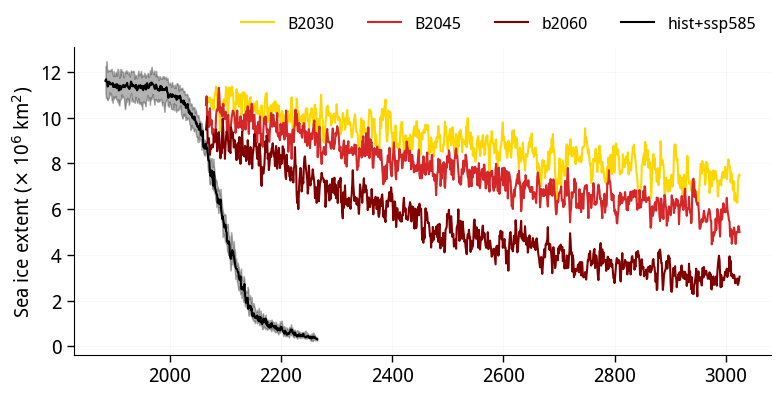

In [34]:
plt.figure(figsize=(9,4))

plt.plot(siext_sh_stable_orig.isel(time = slice(35, -35)).time.dt.year, siext_sh_stable_orig.isel(time = slice(35, -35)).sel(model = '2030'), color='gold', lw=1.5, label='B2030')
# plt.axhline(siext_sh_stable_orig.isel(time = slice(35, -35)).sel(model='B2030').quantile(0.5, dim='time'), color='gold')

# plt.plot(siext_sh_stable_orig.isel(time = slice(35, -35)).time.dt.year, siext_sh_stable_orig.isel(time = slice(35, -35)).sel(model = '2035'), color='tab:orange', lw=1.5, label='B2035', alpha=0.2)
# plt.plot(siext_sh_stable_orig.isel(time = slice(35, -35)).time.dt.year, siext_sh_stable_orig.isel(time = slice(35, -35)).sel(model = '2040'), color='tomato', lw=1.5, label='B2040', alpha=0.2)

plt.plot(siext_sh_stable_orig.isel(time = slice(35, -35)).time.dt.year, siext_sh_stable_orig.isel(time = slice(35, -35)).sel(model = '2045'), color='tab:red', lw=1.5, label='B2045')
# plt.axhline(siext_sh_stable_orig.isel(time = slice(35, -35)).sel(model='B2045').quantile(0.5, dim='time'), color='tab:red')

# plt.plot(siext_sh_stable_orig.isel(time = slice(35, -35)).time.dt.year, siext_sh_stable_orig.isel(time = slice(35, -35)).sel(model = '2050'), color='darkred', lw=1.5, label='B2050', alpha=0.2)
# plt.plot(siext_sh_stable_orig.isel(time = slice(35, -35)).time.dt.year, siext_sh_stable_orig.isel(time = slice(35, -35)).sel(model = '2055'), color='tab:brown', lw=1.5, label='B2055', alpha=0.2)

plt.plot(siext_sh_stable_orig.isel(time = slice(35, -35)).time.dt.year, siext_sh_stable_orig.isel(time = slice(35, -35)).sel(model = '2060'), color='maroon', lw=1.5, label='b2060')
# plt.axhline(siext_sh_stable_orig.isel(time = slice(35, -35)).sel(model='B2060').quantile(0.5, dim='time'), color='maroon')




plt.plot(fix_da(fix_da(siext_sh_trans_orig)).isel(time = slice(35, -35)).time.dt.year, fix_da(fix_da(siext_sh_trans_orig)).isel(time = slice(35, -35)).quantile(0.5, 'model'), color='k', lw=1.5, label='hist+ssp585')
# plt.plot(fix_da(fix_da(siext_sh_trans_orig)).isel(time = slice(35, -35)).time.dt.year, fix_da(fix_da(siext_sh_trans_orig)).isel(time = slice(35, -35)).sel(model='ACCESS-ESM1-5_r10i1p1f1'), color='k', ls='--', lw=1.0, label='hist+ssp5 r10')
plt.fill_between(fix_da(fix_da(siext_sh_trans_orig)).isel(time = slice(35, -35)).time.dt.year, fix_da(fix_da(siext_sh_trans_orig)).isel(time = slice(35, -35)).quantile(0.1, 'model'), fix_da(fix_da(siext_sh_trans_orig)).isel(time = slice(35, -35)).quantile(0.9, 'model'), color='k', alpha=0.3)

# plt.plot(conc_fix_da(fix_da(siext_sh_trans_orig)).isel(time = slice(35, -35)).time.dt.year, conc_fix_da(fix_da(siext_sh_trans_orig)).isel(time = slice(35, -35)).quantile(0.5, 'model'), color='tab:blue', lw=1.5, label='hist+ssp585', alpha=0.3)
# plt.plot(fix_da(fix_da(siext_sh_trans_orig)).isel(time = slice(35, -35)).time.dt.year, fix_da(fix_da(siext_sh_trans_orig)).isel(time = slice(35, -35)).sel(model='ACCESS-ESM1-5_r10i1p1f1'), color='k', ls='--', lw=1.0, label='hist+ssp5 r10')
# plt.fill_between(conc_fix_da(fix_da(siext_sh_trans_orig)).isel(time = slice(35, -35)).time.dt.year, conc_fix_da(fix_da(siext_sh_trans_orig)).isel(time = slice(35, -35)).quantile(0.1, 'model'), conc_fix_da(fix_da(siext_sh_trans_orig)).isel(time = slice(35, -35)).quantile(0.9, 'model'), color='tab:blue', alpha=0.1)

# sns.despine(trim=True)
plt.legend(frameon=False, fontsize=12, loc='lower right', ncol=5, bbox_to_anchor=(1., 1.))
plot_decorator()
plt.ylabel(r'Sea ice extent ($\times$ 10$^{6}$ km$^{2}$)')
# plt.xlabel('Year')


In [ ]:
xr.open_dataset('/g/data/fs')

Text(0, 0.5, 'Sea ice extent ($\\times$ 10$^{6}$ km$^{2}$)')

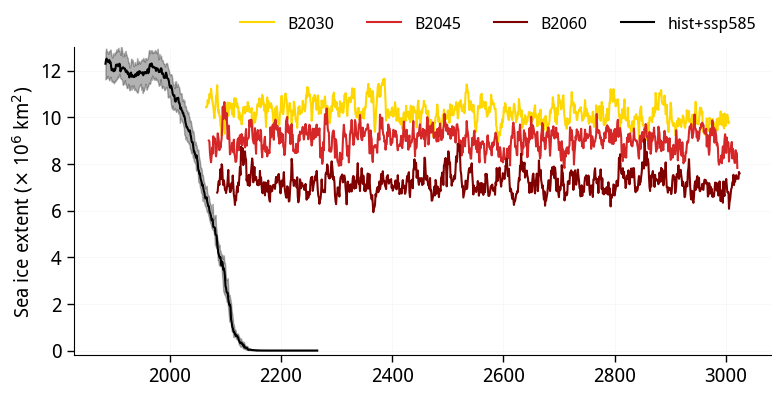

In [38]:
plt.figure(figsize=(9,4))

plt.plot(fix_da(siext_nh_stable_orig).isel(time = slice(35, -35)).time.dt.year, fix_da(siext_nh_stable_orig).isel(time = slice(35, -35)).sel(model = '2030'), color='gold', lw=1.5, label='B2030')
# plt.axhline(fix_da(siext_nh_stable_orig).isel(time = slice(35, -35)).sel(model='B2030').quantile(0.5, dim='time'), color='gold')

plt.plot(fix_da(siext_nh_stable_orig).isel(time = slice(35, -35)).time.dt.year, fix_da(siext_nh_stable_orig).isel(time = slice(35, -35)).sel(model = '2045'), color='tab:red', lw=1.5, label='B2045')
# plt.axhline(fix_da(siext_nh_stable_orig).isel(time = slice(35, -35)).sel(model='B2045').quantile(0.5, dim='time'), color='tab:red')

plt.plot(fix_da(siext_nh_stable_orig).isel(time = slice(35, -35)).time.dt.year, fix_da(siext_nh_stable_orig).isel(time = slice(35, -35)).sel(model = '2060'), color='maroon', lw=1.5, label='B2060')
# plt.axhline(fix_da(siext_nh_stable_orig).isel(time = slice(35, -35)).sel(model='B2060').quantile(0.5, dim='time'), color='maroon')

plt.plot(fix_da(siext_nh_trans_orig).isel(time = slice(35, -35)).time.dt.year, fix_da(siext_nh_trans_orig).isel(time = slice(35, -35)).quantile(0.5, 'model'), color='k', lw=1.5, label='hist+ssp585')
# plt.plot(fix_da(siext_nh_trans_orig).isel(time = slice(35, -35)).time.dt.year, fix_da(siext_nh_trans_orig).isel(time = slice(35, -35)).sel(model='ACCESS-ESM1-5_r10i1p1f1'), color='k', ls='--', lw=1.0, label='hist+ssp5 r10')
plt.fill_between(fix_da(siext_nh_trans_orig).isel(time = slice(35, -35)).time.dt.year, fix_da(siext_nh_trans_orig).isel(time = slice(35, -35)).quantile(0.1, 'model'), fix_da(siext_nh_trans_orig).isel(time = slice(35, -35)).quantile(0.9, 'model'), color='k', alpha=0.3)

# plt.plot(conc_fix_da(siext_nh_trans_orig).isel(time = slice(35, -35)).time.dt.year, conc_fix_da(siext_nh_trans_orig).isel(time = slice(35, -35)).quantile(0.5, 'model'), color='tab:blue', lw=1.5, label='hist+ssp585', alpha=0.3)
# plt.plot(fix_da(siext_nh_trans_orig).isel(time = slice(35, -35)).time.dt.year, fix_da(siext_nh_trans_orig).isel(time = slice(35, -35)).sel(model='ACCESS-ESM1-5_r10i1p1f1'), color='k', ls='--', lw=1.0, label='hist+ssp5 r10')
# plt.fill_between(conc_fix_da(siext_nh_trans_orig).isel(time = slice(35, -35)).time.dt.year, conc_fix_da(siext_nh_trans_orig).isel(time = slice(35, -35)).quantile(0.1, 'model'), conc_fix_da(siext_nh_trans_orig).isel(time = slice(35, -35)).quantile(0.9, 'model'), color='tab:blue', alpha=0.1)

# sns.despine(trim=True)
plt.legend(frameon=False, fontsize=12, loc='lower right', ncol=5, bbox_to_anchor=(1., 1.))
plot_decorator()
plt.ylim(-.2, 13)
plt.ylabel(r'Sea ice extent ($\times$ 10$^{6}$ km$^{2}$)')
# plt.xlabel('Year')


#### indo pacific heat transport

In [16]:
htovovrt_pi = htovovrt_trans_orig.isel(basin=1).sel(time = slice('1850', '1900')).mean('time')
htovovrt_trans_2060 = htovovrt_trans_orig.isel(basin=1).sel(time = slice('2045', '2075')).mean('time')
htovovrt_trans_2045 = htovovrt_trans_orig.isel(basin=1).sel(time = slice('2030', '2060')).mean('time')
htovovrt_trans_2030 = htovovrt_trans_orig.isel(basin=1).sel(time = slice('2015', '2045')).mean('time')

In [17]:
htovgyre_pi = htovgyre_trans_orig.isel(basin=1).sel(time = slice('1850', '1900')).mean('time')
htovgyre_trans_2060 = htovgyre_trans_orig.isel(basin=1).sel(time = slice('2045', '2075')).mean('time')
htovgyre_trans_2045 = htovgyre_trans_orig.isel(basin=1).sel(time = slice('2030', '2060')).mean('time')
htovgyre_trans_2030 = htovgyre_trans_orig.isel(basin=1).sel(time = slice('2015', '2045')).mean('time')

In [18]:
def additional_sampling_stabilisation(da, initiator=100, spacer=30):
    i = initiator
    da_list = []
    while i <= 1000 - spacer:
        sample_da = da.isel(time = slice(i,i+spacer)).mean('time')
        da_list.append(sample_da)
        i += spacer
    print('Done')
    out_da = xr.concat(da_list, dim=np.arange(0, (1000 - initiator)/spacer, 1))
    if 'model' in out_da.coords:
        return out_da.drop('model').rename(dict(concat_dim='model'))
    else:
        return out_da.rename(dict(concat_dim='model'))


def additional_sampling_stabilisation_nomeans(da, initiator=100, spacer=30):
    i = initiator
    da_list = []
    while i <= 1000 - spacer:
        sample_da = da.isel(time = slice(i,i+spacer))
        da_list.append(sample_da)
        i += spacer
    print('Done')
    out_da = xr.concat(da_list, dim=np.arange(0, (1000 - initiator)/spacer, 1))
    if 'model' in out_da.coords:
        return out_da.drop('model').rename(dict(concat_dim='model'))
    else:
        return out_da.rename(dict(concat_dim='model'))


In [19]:
htovovrt_stable_2030 = additional_sampling_stabilisation(htovovrt_stable_orig.isel(basin=1).sel(model = '2030'))
htovovrt_stable_2045 = additional_sampling_stabilisation(htovovrt_stable_orig.isel(basin=1).sel(model = '2045'))
htovovrt_stable_2060 = additional_sampling_stabilisation(htovovrt_stable_orig.isel(basin=1).sel(model = '2060'))

Done
Done
Done


In [20]:
htovgyre_stable_2030 = additional_sampling_stabilisation(htovgyre_stable_orig.isel(basin=1).sel(model = '2030'))
htovgyre_stable_2045 = additional_sampling_stabilisation(htovgyre_stable_orig.isel(basin=1).sel(model = '2045'))
htovgyre_stable_2060 = additional_sampling_stabilisation(htovgyre_stable_orig.isel(basin=1).sel(model = '2060'))

Done
Done
Done


In [21]:
net_ht_pi = htovgyre_pi + htovovrt_pi

net_ht_trans_2030 = htovgyre_trans_2030 + htovovrt_trans_2030
net_ht_trans_2045 = htovgyre_trans_2045 + htovovrt_trans_2045
net_ht_trans_2060 = htovgyre_trans_2060 + htovovrt_trans_2060

net_ht_stable_2030 = htovgyre_stable_2030 + htovovrt_stable_2030
net_ht_stable_2045 = htovgyre_stable_2045 + htovovrt_stable_2045
net_ht_stable_2060 = htovgyre_stable_2060 + htovovrt_stable_2060

In [97]:
import seaborn as sns

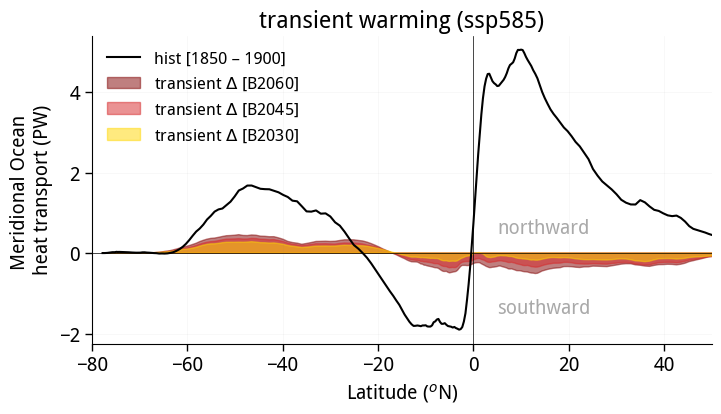

In [71]:
plt.figure(figsize=(8,4))
xdata = htovovrt_pi.lat.to_numpy()

plt.plot(xdata, htovovrt_pi.quantile(0.5, 'model')/1e15, color='k', label='hist [1850 – 1900]')
# plt.fill_between(xdata, htovovrt_pi.quantile(0.1, 'model')/1e15, htovovrt_pi.quantile(0.9, 'model')/1e15, color='k', alpha=0.2)

# plt.plot(xdata, htovovrt_trans_2030.quantile(0.5, 'model')/1e15, color='gold')
# plt.fill_between(xdata, htovovrt_trans_2030.quantile(0.1, 'model')/1e15, htovovrt_trans_2030.quantile(0.9, 'model')/1e15, color='gold', alpha=0.2)

# plt.plot(xdata, htovovrt_trans_2045.quantile(0.5, 'model')/1e15, color='tab:red')

# plt.plot(xdata, htovovrt_trans_2060.quantile(0.5, 'model')/1e15, color='maroon')

plt.fill_between(xdata, 0, (htovovrt_trans_2060.quantile(0.5, 'model') - htovovrt_pi.quantile(0.5, 'model'))/1e15, color='maroon', alpha=0.5, label='transient $\Delta$ [B2060]')
plt.fill_between(xdata, 0, (htovovrt_trans_2045.quantile(0.5, 'model') - htovovrt_pi.quantile(0.5, 'model'))/1e15, color='tab:red', alpha=0.5, label='transient $\Delta$ [B2045]')
plt.fill_between(xdata, 0, (htovovrt_trans_2030.quantile(0.5, 'model') - htovovrt_pi.quantile(0.5, 'model'))/1e15, color='gold', alpha=0.5, label='transient $\Delta$ [B2030]')


plt.ylabel('Meridional Ocean \nheat transport (PW)')
plt.xlabel('Latitude ($^{o}$N)')
# plot_decorator()
plt.axhline(0.0, lw=0.5, color='k')
plt.axvline(0.0, lw=0.5, color='k')
# plt.axvline(-30.0, lw=0.5, color='k', ls='--', alpha=0.2)
# plt.axvline(30.0, lw=0.5, color='k', ls='--', alpha=0.2)
# sns.despine(left=True, right=True)
# plt.grid(alpha=0.05)
plot_decorator()
plt.xlim(-80, 50)
plt.text(5, 0.5, 'northward', size=14, color='darkgray')
plt.text(5, -1.5, 'southward', size=14, color='darkgray')
plt.title('transient warming (ssp585)')
plt.legend(frameon=False, loc='upper left', fontsize=12)

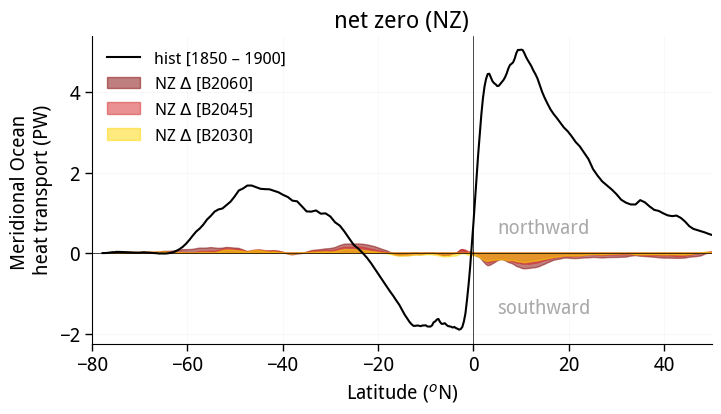

In [72]:
plt.figure(figsize=(8,4))
xdata = htovovrt_pi.lat.to_numpy()

plt.plot(xdata, htovovrt_pi.quantile(0.5, 'model')/1e15, color='k', label='hist [1850 – 1900]')
# plt.fill_between(xdata, htovovrt_pi.quantile(0.1, 'model')/1e15, htovovrt_pi.quantile(0.9, 'model')/1e15, color='k', alpha=0.2)

# plt.plot(xdata, htovovrt_stable_2030.quantile(0.5, 'model')/1e15, color='gold')
# plt.fill_between(xdata, htovovrt_stable_2030.quantile(0.1, 'model')/1e15, htovovrt_stable_2030.quantile(0.9, 'model')/1e15, color='gold', alpha=0.2)

# plt.plot(xdata, htovovrt_stable_2045.quantile(0.5, 'model')/1e15, color='tab:red')

# plt.plot(xdata, htovovrt_stable_2060.quantile(0.5, 'model')/1e15, color='maroon')

plt.fill_between(xdata, 0, (htovovrt_stable_2060.quantile(0.5, 'model') - htovovrt_pi.quantile(0.5, 'model'))/1e15, color='maroon', alpha=0.5, label='NZ $\Delta$ [B2060]')
plt.fill_between(xdata, 0, (htovovrt_stable_2045.quantile(0.5, 'model') - htovovrt_pi.quantile(0.5, 'model'))/1e15, color='tab:red', alpha=0.5, label='NZ $\Delta$ [B2045]')
plt.fill_between(xdata, 0, (htovovrt_stable_2030.quantile(0.5, 'model') - htovovrt_pi.quantile(0.5, 'model'))/1e15, color='gold', alpha=0.5, label='NZ $\Delta$ [B2030]')


plt.ylabel('Meridional Ocean \nheat transport (PW)')
plt.xlabel('Latitude ($^{o}$N)')
# plot_decorator()
plt.axhline(0.0, lw=0.5, color='k')
plt.axvline(0.0, lw=0.5, color='k')
# sns.despine(left=True, right=True)
# plt.grid(alpha=0.05)
plot_decorator()
plt.xlim(-80, 50)
plt.text(5, 0.5, 'northward', size=14, color='darkgray')
plt.text(5, -1.5, 'southward', size=14, color='darkgray')
plt.title('net zero (NZ)')
plt.legend(frameon=False, loc='upper left', fontsize=12)

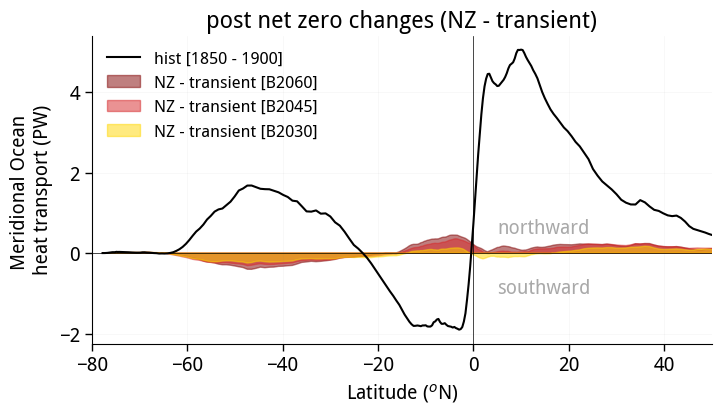

In [73]:
plt.figure(figsize=(8,4))
xdata = htovovrt_pi.lat.to_numpy()

plt.plot(xdata, htovovrt_pi.quantile(0.5, 'model')/1e15, color='k', label='hist [1850 - 1900]')
# plt.fill_between(xdata, htovovrt_pi.quantile(0.1, 'model')/1e15, htovovrt_pi.quantile(0.9, 'model')/1e15, color='k', alpha=0.2)

# plt.plot(xdata, htovovrt_stable_2030.quantile(0.5, 'model')/1e15, color='gold')
# plt.fill_between(xdata, htovovrt_stable_2030.quantile(0.1, 'model')/1e15, htovovrt_stable_2030.quantile(0.9, 'model')/1e15, color='gold', alpha=0.2)

# plt.plot(xdata, htovovrt_stable_2045.quantile(0.5, 'model')/1e15, color='tab:red')

# plt.plot(xdata, htovovrt_stable_2060.quantile(0.5, 'model')/1e15, color='maroon')

plt.fill_between(xdata, 0, (htovovrt_stable_2060.quantile(0.5, 'model') - htovovrt_trans_2060.quantile(0.5, 'model'))/1e15, color='maroon', alpha=0.5, label='NZ - transient [B2060]')
plt.fill_between(xdata, 0, (htovovrt_stable_2045.quantile(0.5, 'model') - htovovrt_trans_2045.quantile(0.5, 'model'))/1e15, color='tab:red', alpha=0.5, label='NZ - transient [B2045]')
plt.fill_between(xdata, 0, (htovovrt_stable_2030.quantile(0.5, 'model') - htovovrt_trans_2030.quantile(0.5, 'model'))/1e15, color='gold', alpha=0.5, label='NZ - transient [B2030]')


plt.ylabel('Meridional Ocean \nheat transport (PW)')
plt.xlabel('Latitude ($^{o}$N)')
# plot_decorator()
plt.axhline(0.0, lw=0.5, color='k')
plt.axvline(0.0, lw=0.5, color='k')
# sns.despine(left=True, right=True)
# plt.grid(alpha=0.05)
plot_decorator()
plt.xlim(-80, 50)
plt.text(5, 0.5, 'northward', size=14, color='darkgray')
plt.text(5, -1.0, 'southward', size=14, color='darkgray')
plt.title('post net zero changes (NZ - transient)')
plt.legend(frameon=False, loc='upper left', fontsize=12)

Done
Done
Done


Text(0, 0.5, 'Meridional Ocean \nheat transport (PW)')

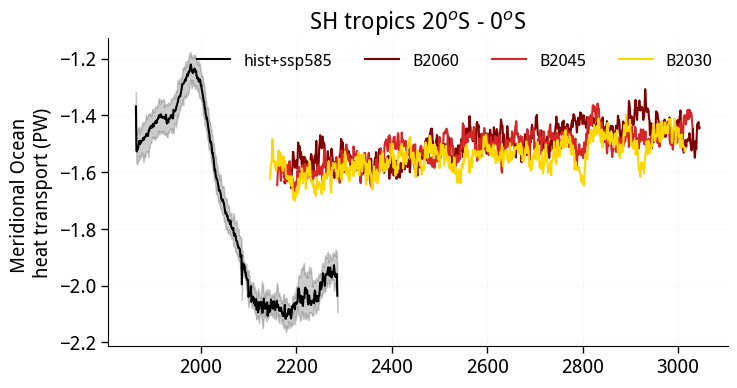

In [39]:
plt.figure(figsize=(8, 4))
data = (htovovrt_trans_orig/1e15).isel(basin=1).sel(lat = slice(-20, 0)).mean(('lat')).rolling(time = 30, center=True).mean('time')
xdata = data.time.dt.year
plt.plot(xdata, data.quantile(0.5, 'model'), color='k', label='hist+ssp585')
plt.fill_between(xdata, data.quantile(0.1, 'model'), data.quantile(0.9, 'model'), color='k', alpha=0.2)

data = additional_sampling_stabilisation_nomeans(((htovovrt_stable_orig/1e15).sel(model = '2060').isel(basin=1).sel(lat = slice(-20, 0)).mean(('lat')).sel(time = slice('2060', '3060'))))
xdata = data.time.dt.year
plt.plot(xdata, data.quantile(0.5, 'model').rolling(time = 30, center=True).mean('time'), color='maroon', label='B2060')
plt.fill_between(xdata, data.quantile(0.1, 'model').rolling(time = 30, center=True).mean('time'), data.quantile(0.9, 'model').rolling(time = 30, center=True).mean('time'), color='maroon', alpha=0.1)

data = additional_sampling_stabilisation_nomeans(((htovovrt_stable_orig/1e15).sel(model = '2045').isel(basin=1).sel(lat = slice(-20, 0)).mean(('lat')).sel(time = slice('2045', '3045'))))
xdata = data.time.dt.year
plt.plot(xdata, data.quantile(0.5, 'model').rolling(time = 30, center=True).mean('time'), color='tab:red', label='B2045')
plt.fill_between(xdata, data.quantile(0.1, 'model').rolling(time = 30, center=True).mean('time'), data.quantile(0.9, 'model').rolling(time = 30, center=True).mean('time'), color='tab:red', alpha=0.1)

data = additional_sampling_stabilisation_nomeans(((htovovrt_stable_orig/1e15).sel(model = '2030').isel(basin=1).sel(lat = slice(-20, 0)).mean(('lat')).sel(time = slice('2030', '3030'))))
xdata = data.time.dt.year
plt.plot(xdata, data.quantile(0.5, 'model').rolling(time = 30, center=True).mean('time'), color='gold', label='B2030')
plt.fill_between(xdata, data.quantile(0.1, 'model').rolling(time = 30, center=True).mean('time'), data.quantile(0.9, 'model').rolling(time = 30, center=True).mean('time'), color='gold', alpha=0.1)

plot_decorator()
plt.legend(frameon=False, ncol=4, fontsize=12)
plt.title('SH tropics 20$^{o}$S - 0$^{o}$S')
plt.ylabel('Meridional Ocean \nheat transport (PW)')

Done
Done
Done


Text(0, 0.5, 'Meridional Ocean \nheat transport (PW)')

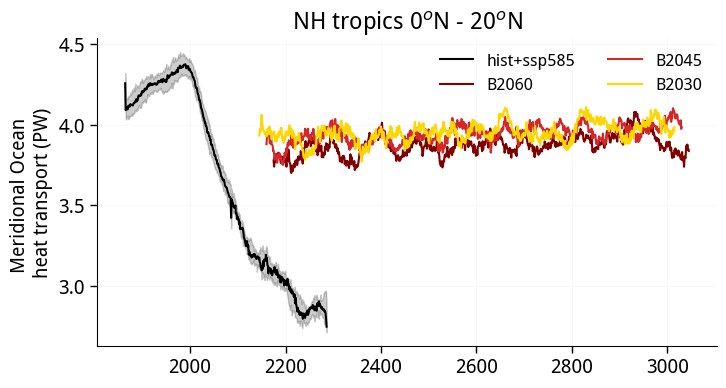

In [78]:
plt.figure(figsize=(8, 4))
data = (htovovrt_trans_orig/1e15).isel(basin=1).sel(lat = slice(0, 20)).mean(('lat')).rolling(time = 30, center=True).mean('time')
xdata = data.time.dt.year
plt.plot(xdata, data.quantile(0.5, 'model'), color='k', label='hist+ssp585')
plt.fill_between(xdata, data.quantile(0.1, 'model'), data.quantile(0.9, 'model'), color='k', alpha=0.2)

data = additional_sampling_stabilisation_nomeans(((htovovrt_stable_orig/1e15).sel(model = '2060').isel(basin=1).sel(lat = slice(0, 20)).mean(('lat')).sel(time = slice('2060', '3060'))))
xdata = data.time.dt.year
plt.plot(xdata, data.quantile(0.5, 'model').rolling(time = 30, center=True).mean('time'), color='maroon', label='B2060')
plt.fill_between(xdata, data.quantile(0.1, 'model').rolling(time = 30, center=True).mean('time'), data.quantile(0.9, 'model').rolling(time = 30, center=True).mean('time'), color='maroon', alpha=0.1)

data = additional_sampling_stabilisation_nomeans(((htovovrt_stable_orig/1e15).sel(model = '2045').isel(basin=1).sel(lat = slice(0, 20)).mean(('lat')).sel(time = slice('2045', '3045'))))
xdata = data.time.dt.year
plt.plot(xdata, data.quantile(0.5, 'model').rolling(time = 30, center=True).mean('time'), color='tab:red', label='B2045')
plt.fill_between(xdata, data.quantile(0.1, 'model').rolling(time = 30, center=True).mean('time'), data.quantile(0.9, 'model').rolling(time = 30, center=True).mean('time'), color='tab:red', alpha=0.1)

data = additional_sampling_stabilisation_nomeans(((htovovrt_stable_orig/1e15).sel(model = '2030').isel(basin=1).sel(lat = slice(0, 20)).mean(('lat')).sel(time = slice('2030', '3030'))))
xdata = data.time.dt.year
plt.plot(xdata, data.quantile(0.5, 'model').rolling(time = 30, center=True).mean('time'), color='gold', label='B2030')
plt.fill_between(xdata, data.quantile(0.1, 'model').rolling(time = 30, center=True).mean('time'), data.quantile(0.9, 'model').rolling(time = 30, center=True).mean('time'), color='gold', alpha=0.1)

plot_decorator()
plt.legend(frameon=False, ncol=2, fontsize=12)
plt.title('NH tropics 0$^{o}$N - 20$^{o}$N')
plt.ylabel('Meridional Ocean \nheat transport (PW)')

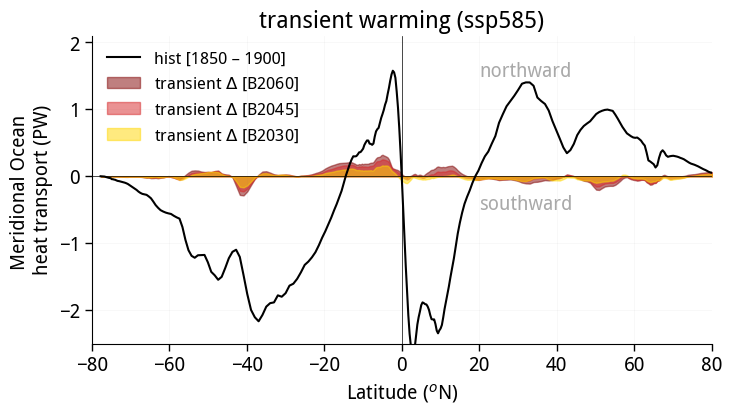

In [70]:
plt.figure(figsize=(8,4))
xdata = htovgyre_pi.lat.to_numpy()

plt.plot(xdata, htovgyre_pi.quantile(0.5, 'model')/1e15, color='k', label='hist [1850 – 1900]')
# plt.fill_between(xdata, htovgyre_pi.quantile(0.1, 'model')/1e15, htovgyre_pi.quantile(0.9, 'model')/1e15, color='k', alpha=0.2)

# plt.plot(xdata, htovgyre_trans_2030.quantile(0.5, 'model')/1e15, color='gold')
# plt.fill_between(xdata, htovgyre_trans_2030.quantile(0.1, 'model')/1e15, htovgyre_trans_2030.quantile(0.9, 'model')/1e15, color='gold', alpha=0.2)

# plt.plot(xdata, htovgyre_trans_2045.quantile(0.5, 'model')/1e15, color='tab:red')

# plt.plot(xdata, htovgyre_trans_2060.quantile(0.5, 'model')/1e15, color='maroon')

plt.fill_between(xdata, 0, (htovgyre_trans_2060.quantile(0.5, 'model') - htovgyre_pi.quantile(0.5, 'model'))/1e15, color='maroon', alpha=0.5, label='transient $\Delta$ [B2060]')
plt.fill_between(xdata, 0, (htovgyre_trans_2045.quantile(0.5, 'model') - htovgyre_pi.quantile(0.5, 'model'))/1e15, color='tab:red', alpha=0.5, label='transient $\Delta$ [B2045]')
plt.fill_between(xdata, 0, (htovgyre_trans_2030.quantile(0.5, 'model') - htovgyre_pi.quantile(0.5, 'model'))/1e15, color='gold', alpha=0.5, label='transient $\Delta$ [B2030]')


plt.ylabel('Meridional Ocean \nheat transport (PW)')
plt.xlabel('Latitude ($^{o}$N)')
# plot_decorator()
plt.axhline(0.0, lw=0.5, color='k')
plt.axvline(0.0, lw=0.5, color='k')
# plt.axvline(-30.0, lw=0.5, color='k', ls='--', alpha=0.2)
# plt.axvline(30.0, lw=0.5, color='k', ls='--', alpha=0.2)
# sns.despine(left=True, right=True)
# plt.grid(alpha=0.05)
plot_decorator()
plt.xlim(-80, 80)
plt.text(20, 1.5, 'northward', size=14, color='darkgray')
plt.text(20, -0.5, 'southward', size=14, color='darkgray')
plt.ylim(-2.5, 2.1)
plt.title('transient warming (ssp585)')
plt.legend(frameon=False, loc='upper left', fontsize=12)

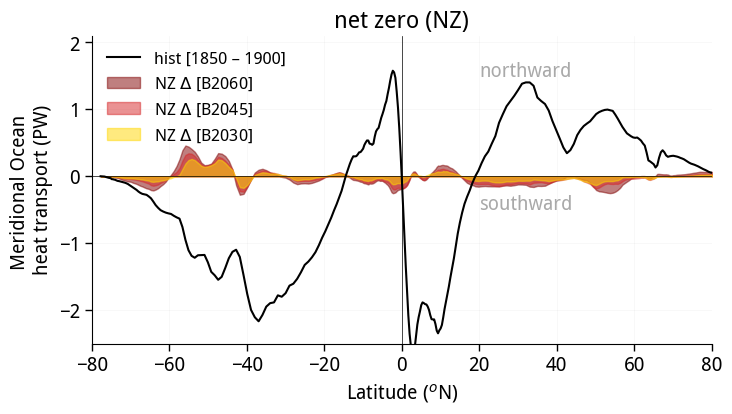

In [69]:
plt.figure(figsize=(8,4))
xdata = htovgyre_pi.lat.to_numpy()

plt.plot(xdata, htovgyre_pi.quantile(0.5, 'model')/1e15, color='k', label='hist [1850 – 1900]')
# plt.fill_between(xdata, htovgyre_pi.quantile(0.1, 'model')/1e15, htovgyre_pi.quantile(0.9, 'model')/1e15, color='k', alpha=0.2)

# plt.plot(xdata, htovgyre_stable_2030.quantile(0.5, 'model')/1e15, color='gold')
# plt.fill_between(xdata, htovgyre_stable_2030.quantile(0.1, 'model')/1e15, htovgyre_stable_2030.quantile(0.9, 'model')/1e15, color='gold', alpha=0.2)

# plt.plot(xdata, htovgyre_stable_2045.quantile(0.5, 'model')/1e15, color='tab:red')

# plt.plot(xdata, htovgyre_stable_2060.quantile(0.5, 'model')/1e15, color='maroon')

plt.fill_between(xdata, 0, (htovgyre_stable_2060.quantile(0.5, 'model') - htovgyre_pi.quantile(0.5, 'model'))/1e15, color='maroon', alpha=0.5, label='NZ $\Delta$ [B2060]')
plt.fill_between(xdata, 0, (htovgyre_stable_2045.quantile(0.5, 'model') - htovgyre_pi.quantile(0.5, 'model'))/1e15, color='tab:red', alpha=0.5, label='NZ $\Delta$ [B2045]')
plt.fill_between(xdata, 0, (htovgyre_stable_2030.quantile(0.5, 'model') - htovgyre_pi.quantile(0.5, 'model'))/1e15, color='gold', alpha=0.5, label='NZ $\Delta$ [B2030]')


plt.ylabel('Meridional Ocean \nheat transport (PW)')
plt.xlabel('Latitude ($^{o}$N)')
# plot_decorator()
plt.axhline(0.0, lw=0.5, color='k')
plt.axvline(0.0, lw=0.5, color='k')
# sns.despine(left=True, right=True)
# plt.grid(alpha=0.05)
plot_decorator()
plt.xlim(-80, 80)
plt.text(20, 1.5, 'northward', size=14, color='darkgray')
plt.text(20, -0.5, 'southward', size=14, color='darkgray')
plt.ylim(-2.5, 2.1)
plt.title('net zero (NZ)')
plt.legend(frameon=False, loc='upper left', fontsize=12)

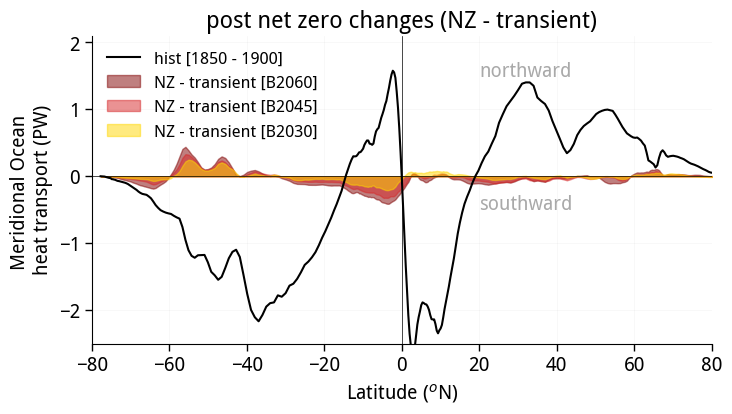

In [68]:
plt.figure(figsize=(8,4))
xdata = htovgyre_pi.lat.to_numpy()

plt.plot(xdata, htovgyre_pi.quantile(0.5, 'model')/1e15, color='k', label='hist [1850 - 1900]')
# plt.fill_between(xdata, htovgyre_pi.quantile(0.1, 'model')/1e15, htovgyre_pi.quantile(0.9, 'model')/1e15, color='k', alpha=0.2)

# plt.plot(xdata, htovgyre_stable_2030.quantile(0.5, 'model')/1e15, color='gold')
# plt.fill_between(xdata, htovgyre_stable_2030.quantile(0.1, 'model')/1e15, htovgyre_stable_2030.quantile(0.9, 'model')/1e15, color='gold', alpha=0.2)

# plt.plot(xdata, htovgyre_stable_2045.quantile(0.5, 'model')/1e15, color='tab:red')

# plt.plot(xdata, htovgyre_stable_2060.quantile(0.5, 'model')/1e15, color='maroon')

plt.fill_between(xdata, 0, (htovgyre_stable_2060.quantile(0.5, 'model') - htovgyre_trans_2060.quantile(0.5, 'model'))/1e15, color='maroon', alpha=0.5, label='NZ - transient [B2060]')
plt.fill_between(xdata, 0, (htovgyre_stable_2045.quantile(0.5, 'model') - htovgyre_trans_2045.quantile(0.5, 'model'))/1e15, color='tab:red', alpha=0.5, label='NZ - transient [B2045]')
plt.fill_between(xdata, 0, (htovgyre_stable_2030.quantile(0.5, 'model') - htovgyre_trans_2030.quantile(0.5, 'model'))/1e15, color='gold', alpha=0.5, label='NZ - transient [B2030]')


plt.ylabel('Meridional Ocean \nheat transport (PW)')
plt.xlabel('Latitude ($^{o}$N)')
# plot_decorator()
plt.axhline(0.0, lw=0.5, color='k')
plt.axvline(0.0, lw=0.5, color='k')
# sns.despine(left=True, right=True)
# plt.grid(alpha=0.05)
plot_decorator()
plt.xlim(-80, 80)
plt.text(20, 1.5, 'northward', size=14, color='darkgray')
plt.text(20, -0.5, 'southward', size=14, color='darkgray')
plt.ylim(-2.5, 2.1)
plt.title('post net zero changes (NZ - transient)')
plt.legend(frameon=False, loc='upper left', fontsize=12)

Done
Done
Done


Text(0, 0.5, 'Meridional Ocean \nheat transport (PW)')

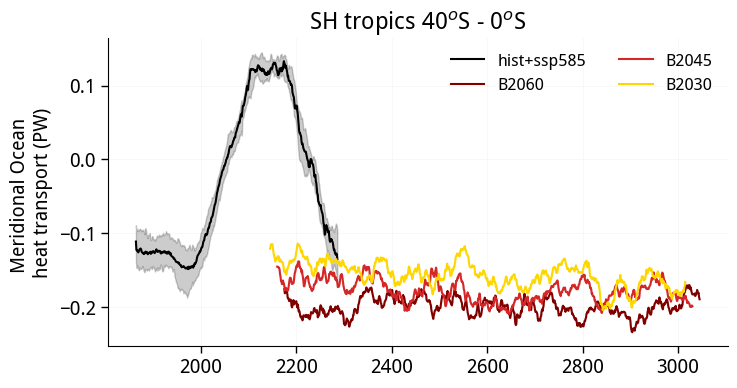

In [82]:
plt.figure(figsize=(8, 4))
data = (htovgyre_trans_orig/1e15).isel(basin=1).sel(lat = slice(-40, 0)).mean(('lat')).rolling(time = 30, center=True).mean('time')
xdata = data.time.dt.year
plt.plot(xdata, data.quantile(0.5, 'model'), color='k', label='hist+ssp585')
plt.fill_between(xdata, data.quantile(0.1, 'model'), data.quantile(0.9, 'model'), color='k', alpha=0.2)

data = additional_sampling_stabilisation_nomeans(((htovgyre_stable_orig/1e15).sel(model = '2060').isel(basin=1).sel(lat = slice(-40, 0)).mean(('lat')).sel(time = slice('2060', '3060'))))
xdata = data.time.dt.year
plt.plot(xdata, data.quantile(0.5, 'model').rolling(time = 30, center=True).mean('time'), color='maroon', label='B2060')
plt.fill_between(xdata, data.quantile(0.1, 'model').rolling(time = 30, center=True).mean('time'), data.quantile(0.9, 'model').rolling(time = 30, center=True).mean('time'), color='maroon', alpha=0.1)

data = additional_sampling_stabilisation_nomeans(((htovgyre_stable_orig/1e15).sel(model = '2045').isel(basin=1).sel(lat = slice(-40, 0)).mean(('lat')).sel(time = slice('2045', '3045'))))
xdata = data.time.dt.year
plt.plot(xdata, data.quantile(0.5, 'model').rolling(time = 30, center=True).mean('time'), color='tab:red', label='B2045')
plt.fill_between(xdata, data.quantile(0.1, 'model').rolling(time = 30, center=True).mean('time'), data.quantile(0.9, 'model').rolling(time = 30, center=True).mean('time'), color='tab:red', alpha=0.1)

data = additional_sampling_stabilisation_nomeans(((htovgyre_stable_orig/1e15).sel(model = '2030').isel(basin=1).sel(lat = slice(-40, 0)).mean(('lat')).sel(time = slice('2030', '3030'))))
xdata = data.time.dt.year
plt.plot(xdata, data.quantile(0.5, 'model').rolling(time = 30, center=True).mean('time'), color='gold', label='B2030')
plt.fill_between(xdata, data.quantile(0.1, 'model').rolling(time = 30, center=True).mean('time'), data.quantile(0.9, 'model').rolling(time = 30, center=True).mean('time'), color='gold', alpha=0.1)

plot_decorator()
plt.legend(frameon=False, ncol=2, fontsize=12)
plt.title('SH tropics 40$^{o}$S - 0$^{o}$S')
plt.ylabel('Meridional Ocean \nheat transport (PW)')

Done
Done
Done


Text(0, 0.5, 'Meridional Ocean \nheat transport (PW)')

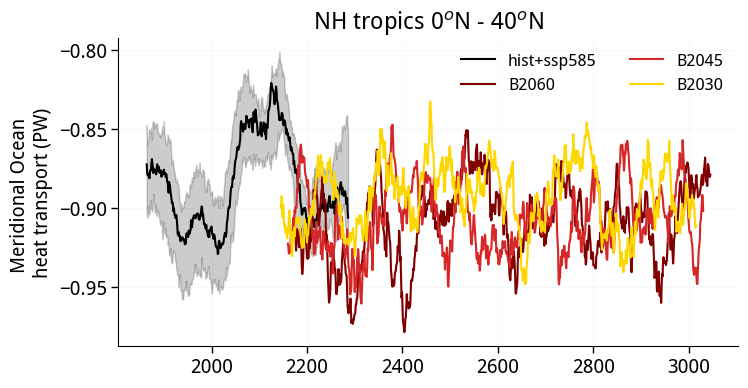

In [81]:
plt.figure(figsize=(8, 4))
data = (htovgyre_trans_orig/1e15).isel(basin=1).sel(lat = slice(0, 40)).mean(('lat')).rolling(time = 30, center=True).mean('time')
xdata = data.time.dt.year
plt.plot(xdata, data.quantile(0.5, 'model'), color='k', label='hist+ssp585')
plt.fill_between(xdata, data.quantile(0.1, 'model'), data.quantile(0.9, 'model'), color='k', alpha=0.2)

data = additional_sampling_stabilisation_nomeans(((htovgyre_stable_orig/1e15).sel(model = '2060').isel(basin=1).sel(lat = slice(0, 40)).mean(('lat')).sel(time = slice('2060', '3060'))))
xdata = data.time.dt.year
plt.plot(xdata, data.quantile(0.5, 'model').rolling(time = 30, center=True).mean('time'), color='maroon', label='B2060')
plt.fill_between(xdata, data.quantile(0.1, 'model').rolling(time = 30, center=True).mean('time'), data.quantile(0.9, 'model').rolling(time = 30, center=True).mean('time'), color='maroon', alpha=0.1)

data = additional_sampling_stabilisation_nomeans(((htovgyre_stable_orig/1e15).sel(model = '2045').isel(basin=1).sel(lat = slice(0, 40)).mean(('lat')).sel(time = slice('2045', '3045'))))
xdata = data.time.dt.year
plt.plot(xdata, data.quantile(0.5, 'model').rolling(time = 30, center=True).mean('time'), color='tab:red', label='B2045')
plt.fill_between(xdata, data.quantile(0.1, 'model').rolling(time = 30, center=True).mean('time'), data.quantile(0.9, 'model').rolling(time = 30, center=True).mean('time'), color='tab:red', alpha=0.1)

data = additional_sampling_stabilisation_nomeans(((htovgyre_stable_orig/1e15).sel(model = '2030').isel(basin=1).sel(lat = slice(0, 40)).mean(('lat')).sel(time = slice('2030', '3030'))))
xdata = data.time.dt.year
plt.plot(xdata, data.quantile(0.5, 'model').rolling(time = 30, center=True).mean('time'), color='gold', label='B2030')
plt.fill_between(xdata, data.quantile(0.1, 'model').rolling(time = 30, center=True).mean('time'), data.quantile(0.9, 'model').rolling(time = 30, center=True).mean('time'), color='gold', alpha=0.1)

plot_decorator()
plt.legend(frameon=False, ncol=2, fontsize=12)
plt.title('NH tropics 0$^{o}$N - 40$^{o}$N')
plt.ylabel('Meridional Ocean \nheat transport (PW)')

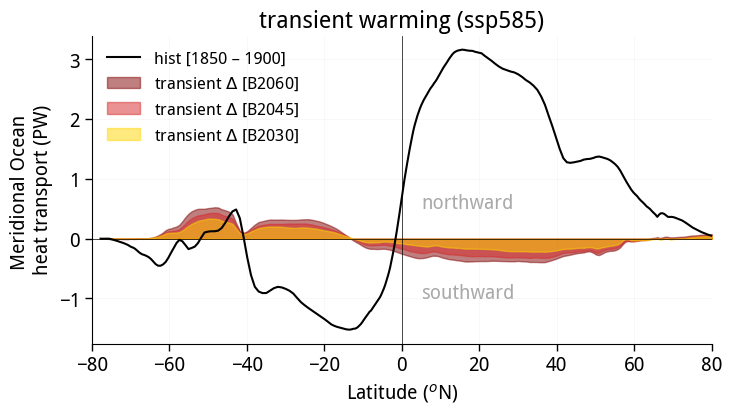

In [86]:
plt.figure(figsize=(8,4))
xdata = net_ht_pi.lat.to_numpy()

plt.plot(xdata, net_ht_pi.quantile(0.5, 'model')/1e15, color='k', label='hist [1850 – 1900]')
# plt.fill_between(xdata, net_ht_pi.quantile(0.1, 'model')/1e15, net_ht_pi.quantile(0.9, 'model')/1e15, color='k', alpha=0.2)

# plt.plot(xdata, net_ht_trans_2030.quantile(0.5, 'model')/1e15, color='gold')
# plt.fill_between(xdata, net_ht_trans_2030.quantile(0.1, 'model')/1e15, net_ht_trans_2030.quantile(0.9, 'model')/1e15, color='gold', alpha=0.2)

# plt.plot(xdata, net_ht_trans_2045.quantile(0.5, 'model')/1e15, color='tab:red')

# plt.plot(xdata, net_ht_trans_2060.quantile(0.5, 'model')/1e15, color='maroon')

plt.fill_between(xdata, 0, (net_ht_trans_2060.quantile(0.5, 'model') - net_ht_pi.quantile(0.5, 'model'))/1e15, color='maroon', alpha=0.5, label='transient $\Delta$ [B2060]')
plt.fill_between(xdata, 0, (net_ht_trans_2045.quantile(0.5, 'model') - net_ht_pi.quantile(0.5, 'model'))/1e15, color='tab:red', alpha=0.5, label='transient $\Delta$ [B2045]')
plt.fill_between(xdata, 0, (net_ht_trans_2030.quantile(0.5, 'model') - net_ht_pi.quantile(0.5, 'model'))/1e15, color='gold', alpha=0.5, label='transient $\Delta$ [B2030]')


plt.ylabel('Meridional Ocean \nheat transport (PW)')
plt.xlabel('Latitude ($^{o}$N)')
# plot_decorator()
plt.axhline(0.0, lw=0.5, color='k')
plt.axvline(0.0, lw=0.5, color='k')
# plt.axvline(-30.0, lw=0.5, color='k', ls='--', alpha=0.2)
# plt.axvline(30.0, lw=0.5, color='k', ls='--', alpha=0.2)
# sns.despine(left=True, right=True)
# plt.grid(alpha=0.05)
plot_decorator()
plt.xlim(-80, 80)
plt.text(5, 0.5, 'northward', size=14, color='darkgray')
plt.text(5, -1.0, 'southward', size=14, color='darkgray')
plt.title('transient warming (ssp585)')
plt.legend(frameon=False, loc='upper left', fontsize=12)

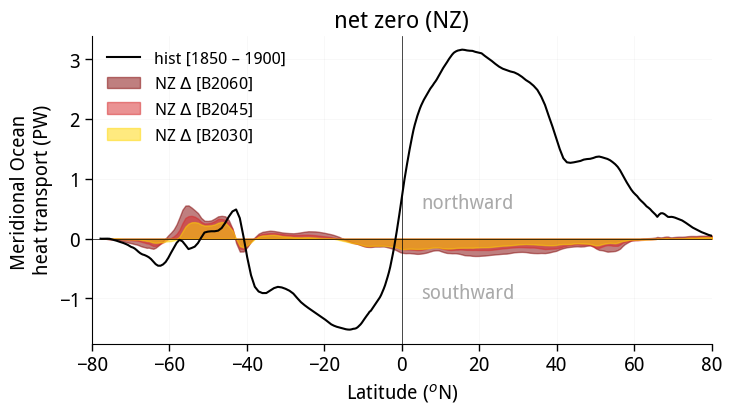

In [66]:
plt.figure(figsize=(8,4))
xdata = net_ht_pi.lat.to_numpy()

plt.plot(xdata, net_ht_pi.quantile(0.5, 'model')/1e15, color='k', label='hist [1850 – 1900]')
# plt.fill_between(xdata, net_ht_pi.quantile(0.1, 'model')/1e15, net_ht_pi.quantile(0.9, 'model')/1e15, color='k', alpha=0.2)

# plt.plot(xdata, net_ht_stable_2030.quantile(0.5, 'model')/1e15, color='gold')
# plt.fill_between(xdata, net_ht_stable_2030.quantile(0.1, 'model')/1e15, net_ht_stable_2030.quantile(0.9, 'model')/1e15, color='gold', alpha=0.2)

# plt.plot(xdata, net_ht_stable_2045.quantile(0.5, 'model')/1e15, color='tab:red')

# plt.plot(xdata, net_ht_stable_2060.quantile(0.5, 'model')/1e15, color='maroon')

plt.fill_between(xdata, 0, (net_ht_stable_2060.quantile(0.5, 'model') - net_ht_pi.quantile(0.5, 'model'))/1e15, color='maroon', alpha=0.5, label='NZ $\Delta$ [B2060]')
plt.fill_between(xdata, 0, (net_ht_stable_2045.quantile(0.5, 'model') - net_ht_pi.quantile(0.5, 'model'))/1e15, color='tab:red', alpha=0.5, label='NZ $\Delta$ [B2045]')
plt.fill_between(xdata, 0, (net_ht_stable_2030.quantile(0.5, 'model') - net_ht_pi.quantile(0.5, 'model'))/1e15, color='gold', alpha=0.5, label='NZ $\Delta$ [B2030]')


plt.ylabel('Meridional Ocean \nheat transport (PW)')
plt.xlabel('Latitude ($^{o}$N)')
# plot_decorator()
plt.axhline(0.0, lw=0.5, color='k')
plt.axvline(0.0, lw=0.5, color='k')
# sns.despine(left=True, right=True)
# plt.grid(alpha=0.05)
plot_decorator()
plt.xlim(-80, 80)
plt.text(5, 0.5, 'northward', size=14, color='darkgray')
plt.text(5, -1.0, 'southward', size=14, color='darkgray')
plt.title('net zero (NZ)')
plt.legend(frameon=False, loc='upper left', fontsize=12)

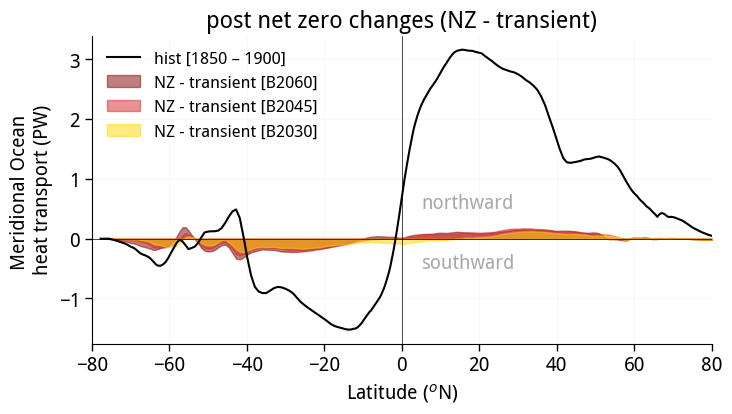

In [85]:
plt.figure(figsize=(8,4))
xdata = net_ht_pi.lat.to_numpy()

plt.plot(xdata, net_ht_pi.quantile(0.5, 'model')/1e15, color='k', label='hist [1850 – 1900]')
# plt.fill_between(xdata, net_ht_pi.quantile(0.1, 'model')/1e15, net_ht_pi.quantile(0.9, 'model')/1e15, color='k', alpha=0.2)

# plt.plot(xdata, net_ht_stable_2030.quantile(0.5, 'model')/1e15, color='gold')
# plt.fill_between(xdata, net_ht_stable_2030.quantile(0.1, 'model')/1e15, net_ht_stable_2030.quantile(0.9, 'model')/1e15, color='gold', alpha=0.2)

# plt.plot(xdata, net_ht_stable_2045.quantile(0.5, 'model')/1e15, color='tab:red')

# plt.plot(xdata, net_ht_stable_2060.quantile(0.5, 'model')/1e15, color='maroon')

plt.fill_between(xdata, 0, (net_ht_stable_2060.quantile(0.5, 'model') - net_ht_trans_2060.quantile(0.5, 'model'))/1e15, color='maroon', alpha=0.5, label='NZ - transient [B2060]')
plt.fill_between(xdata, 0, (net_ht_stable_2045.quantile(0.5, 'model') - net_ht_trans_2045.quantile(0.5, 'model'))/1e15, color='tab:red', alpha=0.5, label='NZ - transient [B2045]')
plt.fill_between(xdata, 0, (net_ht_stable_2030.quantile(0.5, 'model') - net_ht_trans_2030.quantile(0.5, 'model'))/1e15, color='gold', alpha=0.5, label='NZ - transient [B2030]')


plt.ylabel('Meridional Ocean \nheat transport (PW)')
plt.xlabel('Latitude ($^{o}$N)')
# plot_decorator()
plt.axhline(0.0, lw=0.5, color='k')
plt.axvline(0.0, lw=0.5, color='k')
# sns.despine(left=True, right=True)
# plt.grid(alpha=0.05)
plot_decorator()
plt.xlim(-80, 80)
plt.text(5, 0.5, 'northward', size=14, color='darkgray')
plt.text(5, -0.5, 'southward', size=14, color='darkgray')
# plt.ylim(-0.42, 0.45)
plt.title('post net zero changes (NZ - transient)')
plt.legend(frameon=False, loc='upper left', fontsize=12)

In [24]:
net_ht_trans_orig = htovovrt_trans_orig + htovgyre_trans_orig
net_ht_stable_orig = htovovrt_stable_orig + htovgyre_stable_orig

Done
Done
Done


Text(0, 0.5, 'Meridional Ocean \nheat transport (PW)')

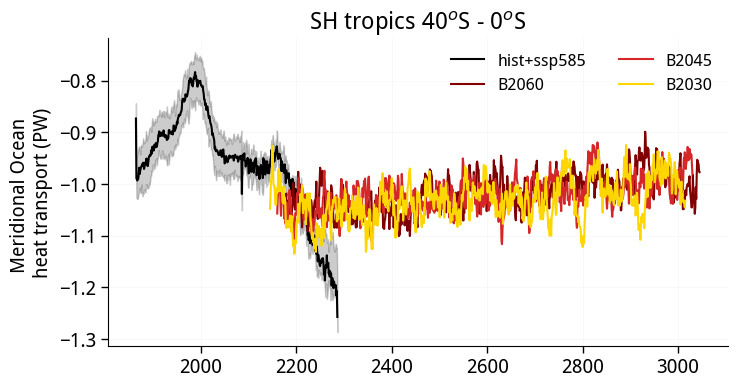

In [79]:
plt.figure(figsize=(8, 4))
data = (net_ht_trans_orig/1e15).isel(basin=1).sel(lat = slice(-40, 0)).mean(('lat')).rolling(time = 30, center=True).mean('time')
xdata = data.time.dt.year
plt.plot(xdata, data.quantile(0.5, 'model'), color='k', label='hist+ssp585')
plt.fill_between(xdata, data.quantile(0.1, 'model'), data.quantile(0.9, 'model'), color='k', alpha=0.2)

data = additional_sampling_stabilisation_nomeans(((net_ht_stable_orig/1e15).sel(model = '2060').isel(basin=1).sel(lat = slice(-40, 0)).mean(('lat')).sel(time = slice('2060', '3060'))))
xdata = data.time.dt.year
plt.plot(xdata, data.quantile(0.5, 'model').rolling(time = 30, center=True).mean('time'), color='maroon', label='B2060')
plt.fill_between(xdata, data.quantile(0.1, 'model').rolling(time = 30, center=True).mean('time'), data.quantile(0.9, 'model').rolling(time = 30, center=True).mean('time'), color='maroon', alpha=0.1)

data = additional_sampling_stabilisation_nomeans(((net_ht_stable_orig/1e15).sel(model = '2045').isel(basin=1).sel(lat = slice(-40, 0)).mean(('lat')).sel(time = slice('2045', '3045'))))
xdata = data.time.dt.year
plt.plot(xdata, data.quantile(0.5, 'model').rolling(time = 30, center=True).mean('time'), color='tab:red', label='B2045')
plt.fill_between(xdata, data.quantile(0.1, 'model').rolling(time = 30, center=True).mean('time'), data.quantile(0.9, 'model').rolling(time = 30, center=True).mean('time'), color='tab:red', alpha=0.1)

data = additional_sampling_stabilisation_nomeans(((net_ht_stable_orig/1e15).sel(model = '2030').isel(basin=1).sel(lat = slice(-40, 0)).mean(('lat')).sel(time = slice('2030', '3030'))))
xdata = data.time.dt.year
plt.plot(xdata, data.quantile(0.5, 'model').rolling(time = 30, center=True).mean('time'), color='gold', label='B2030')
plt.fill_between(xdata, data.quantile(0.1, 'model').rolling(time = 30, center=True).mean('time'), data.quantile(0.9, 'model').rolling(time = 30, center=True).mean('time'), color='gold', alpha=0.1)

plot_decorator()
plt.legend(frameon=False, ncol=2, fontsize=12)
plt.title('SH tropics 40$^{o}$S - 0$^{o}$S')
plt.ylabel('Meridional Ocean \nheat transport (PW)')

Done
Done
Done


Text(0, 0.5, 'Meridional Ocean \nheat transport (PW)')

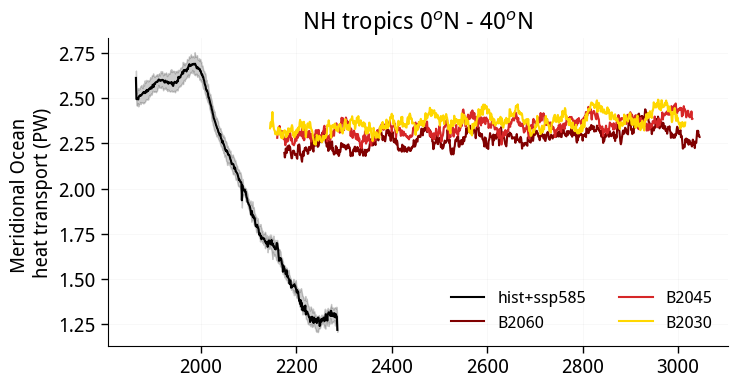

In [80]:
plt.figure(figsize=(8, 4))
data = (net_ht_trans_orig/1e15).isel(basin=1).sel(lat = slice(0, 40)).mean(('lat')).rolling(time = 30, center=True).mean('time')
xdata = data.time.dt.year
plt.plot(xdata, data.quantile(0.5, 'model'), color='k', label='hist+ssp585')
plt.fill_between(xdata, data.quantile(0.1, 'model'), data.quantile(0.9, 'model'), color='k', alpha=0.2)

data = additional_sampling_stabilisation_nomeans(((net_ht_stable_orig/1e15).sel(model = '2060').isel(basin=1).sel(lat = slice(0, 40)).mean(('lat')).sel(time = slice('2060', '3060'))))
xdata = data.time.dt.year
plt.plot(xdata, data.quantile(0.5, 'model').rolling(time = 30, center=True).mean('time'), color='maroon', label='B2060')
plt.fill_between(xdata, data.quantile(0.1, 'model').rolling(time = 30, center=True).mean('time'), data.quantile(0.9, 'model').rolling(time = 30, center=True).mean('time'), color='maroon', alpha=0.1)

data = additional_sampling_stabilisation_nomeans(((net_ht_stable_orig/1e15).sel(model = '2045').isel(basin=1).sel(lat = slice(0, 40)).mean(('lat')).sel(time = slice('2045', '3045'))))
xdata = data.time.dt.year
plt.plot(xdata, data.quantile(0.5, 'model').rolling(time = 30, center=True).mean('time'), color='tab:red', label='B2045')
plt.fill_between(xdata, data.quantile(0.1, 'model').rolling(time = 30, center=True).mean('time'), data.quantile(0.9, 'model').rolling(time = 30, center=True).mean('time'), color='tab:red', alpha=0.1)

data = additional_sampling_stabilisation_nomeans(((net_ht_stable_orig/1e15).sel(model = '2030').isel(basin=1).sel(lat = slice(0, 40)).mean(('lat')).sel(time = slice('2030', '3030'))))
xdata = data.time.dt.year
plt.plot(xdata, data.quantile(0.5, 'model').rolling(time = 30, center=True).mean('time'), color='gold', label='B2030')
plt.fill_between(xdata, data.quantile(0.1, 'model').rolling(time = 30, center=True).mean('time'), data.quantile(0.9, 'model').rolling(time = 30, center=True).mean('time'), color='gold', alpha=0.1)

plot_decorator()
plt.legend(frameon=False, ncol=2, fontsize=12)
plt.title('NH tropics 0$^{o}$N - 40$^{o}$N')
plt.ylabel('Meridional Ocean \nheat transport (PW)')